<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Analysis-Python/blob/main/04_btc_gold_correlation_critique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  3 of 3 completed
/tmp/ipykernel_683/1053032429.py:17: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


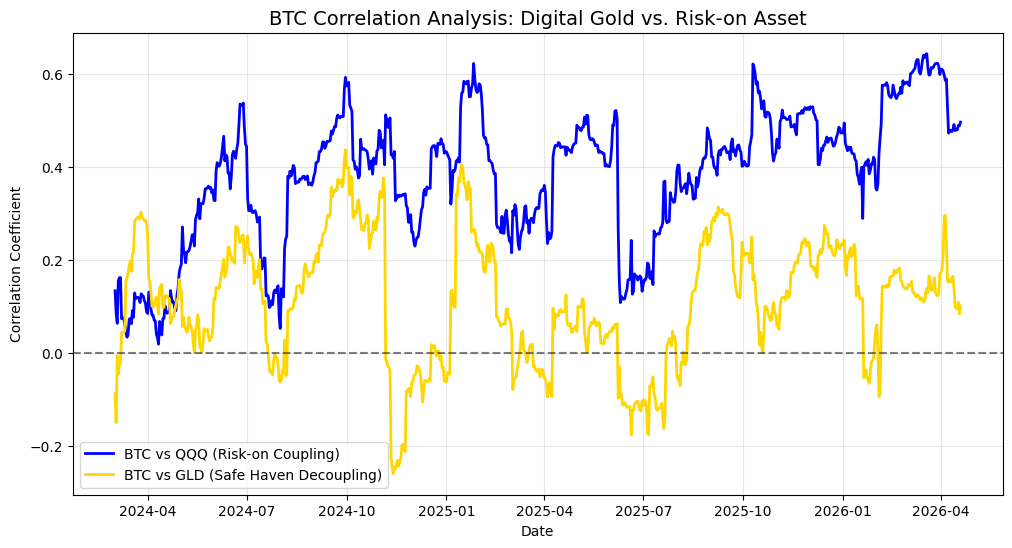

--- Correlation Summary ---
Ticker
BTC-USD    1.000000
QQQ        0.363352
GLD        0.094548
Name: BTC-USD, dtype: float64


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Tickers and Data Range
# BTC-USD (Bitcoin), GLD (Gold), QQQ (Nasdaq 100)
tickers = ['BTC-USD', 'GLD', 'QQQ']
start_date = "2024-01-01"
end_date = "2026-04-20"

# 2. Download Data
# Using auto_adjust=True to handle corporate actions/splits
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

# 3. Calculate Daily Returns
returns = data.pct_change().dropna()

# 4. 60-Day Rolling Correlation
# Verifying if BTC follows Gold (Safe Haven) or QQQ (Risk-on)
rolling_corr_qqq = returns['BTC-USD'].rolling(60).corr(returns['QQQ'])
rolling_corr_gld = returns['BTC-USD'].rolling(60).corr(returns['GLD'])

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.plot(rolling_corr_qqq, label='BTC vs QQQ (Risk-on Coupling)', color='blue', lw=2)
plt.plot(rolling_corr_gld, label='BTC vs GLD (Safe Haven Decoupling)', color='gold', lw=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("BTC Correlation Analysis: Digital Gold vs. Risk-on Asset", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Correlation Coefficient")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Summary Statistics for Interview Prep
print("--- Correlation Summary ---")
print(returns.corr()['BTC-USD'].sort_values(ascending=False))